In [2]:
# Import depedencies
from datetime import datetime
from PIL import Image, ImageDraw
import os
import glob
import pandas as pd
from IPython.display import display
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

pd.set_option('display.max_columns', None)

# Google Screenshot to Analyze
## Path to a google screenshot image in your file explorer

In [3]:
source_folder = r"C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey"
day_folder = r"09_18_2026"
image_file = 'Port Liberty New Jersey_2026-09-18_1221.png'

image_path = source_folder + "\\" + day_folder + "\\" + image_file
image_path

'C:\\Users\\dane.rini\\Global Infrastructure\\SSC PANYNJ Team - Documents\\01 - PANYNJ\\10 - Google Screenshot\\01 - All Inbound Google Screenshots\\Port Liberty New Jersey\\09_18_2026\\Port Liberty New Jersey_2026-09-18_1221.png'

# ROI Selection tool
## Function to draw analysis polygons on your study image

In [21]:
polygon_points = []
polygon_closed = False

rectangle_start = None
rectangle_end = None
drawing_rectangle = False

panning = False
pan_start_mouse = None
pan_start_view = None

mode = 'polygon'  # 'polygon' or 'rectangle'

img = None

# Zoom / view state
zoom = 1.0
min_zoom = 0.2
max_zoom = 12.0
zoom_step = 1.2

view_x = 0  # top-left x of visible area in SCALED image coords
view_y = 0  # top-left y of visible area in SCALED image coords

window_name = "Image"
window_w = None
window_h = None


# ----------------------------
# Helpers
# ----------------------------
def clamp_view():
    """Keep the viewport within the bounds of the scaled image."""
    global view_x, view_y, zoom, img, window_w, window_h

    scaled_w = max(1, int(img.shape[1] * zoom))
    scaled_h = max(1, int(img.shape[0] * zoom))

    max_x = max(0, scaled_w - window_w)
    max_y = max(0, scaled_h - window_h)

    view_x = max(0, min(view_x, max_x))
    view_y = max(0, min(view_y, max_y))


def screen_to_image(x, y):
    """
    Convert display-window coords to ORIGINAL image coords.
    """
    img_x = int((view_x + x) / zoom)
    img_y = int((view_y + y) / zoom)

    img_x = max(0, min(img_x, img.shape[1] - 1))
    img_y = max(0, min(img_y, img.shape[0] - 1))
    return img_x, img_y


def zoom_at(x, y, factor):
    """
    Zoom centered on the mouse position, preserving the image point under the cursor.
    x, y are window/display coords.
    """
    global zoom, view_x, view_y

    old_zoom = zoom
    new_zoom = max(min_zoom, min(max_zoom, zoom * factor))

    if abs(new_zoom - old_zoom) < 1e-9:
        return

    # Original image coords under cursor before zoom
    img_x = (view_x + x) / old_zoom
    img_y = (view_y + y) / old_zoom

    zoom = new_zoom

    # Keep same image point under cursor after zoom
    view_x = int(img_x * zoom - x)
    view_y = int(img_y * zoom - y)

    clamp_view()


def reset_view():
    global zoom, view_x, view_y
    zoom = 1.0
    view_x = 0
    view_y = 0
    clamp_view()


def clear_current_selection():
    global polygon_points, polygon_closed
    global rectangle_start, rectangle_end, drawing_rectangle

    polygon_points = []
    polygon_closed = False
    rectangle_start = None
    rectangle_end = None
    drawing_rectangle = False


def get_display_image():
    """
    Build the displayed image by:
    1) scaling the base image
    2) drawing overlays in scaled coords
    3) cropping to the viewport
    """
    global img, zoom, view_x, view_y, window_w, window_h
    global polygon_points, polygon_closed
    global rectangle_start, rectangle_end

    scaled_w = max(1, int(img.shape[1] * zoom))
    scaled_h = max(1, int(img.shape[0] * zoom))
    scaled = cv2.resize(img, (scaled_w, scaled_h), interpolation=cv2.INTER_LINEAR)

    # Draw polygon
    if polygon_points:
        scaled_pts = [(int(px * zoom), int(py * zoom)) for px, py in polygon_points]

        for pt in scaled_pts:
            cv2.circle(scaled, pt, 5, (0, 0, 0), -1)

        for i in range(1, len(scaled_pts)):
            cv2.line(scaled, scaled_pts[i - 1], scaled_pts[i], (0, 0, 255), 2)

        if polygon_closed and len(scaled_pts) > 2:
            cv2.line(scaled, scaled_pts[-1], scaled_pts[0], (0, 0, 255), 2)

    # Draw rectangle
    if rectangle_start and rectangle_end:
        p1 = (int(rectangle_start[0] * zoom), int(rectangle_start[1] * zoom))
        p2 = (int(rectangle_end[0] * zoom), int(rectangle_end[1] * zoom))
        cv2.rectangle(scaled, p1, p2, (255, 0, 0), 2)

    clamp_view()

    # Crop viewport
    x1 = view_x
    y1 = view_y
    x2 = min(view_x + window_w, scaled_w)
    y2 = min(view_y + window_h, scaled_h)

    cropped = scaled[y1:y2, x1:x2].copy()

    # Pad if needed (when image smaller than window)
    if cropped.shape[1] < window_w or cropped.shape[0] < window_h:
        canvas = np.full((window_h, window_w, 3), 220, dtype=np.uint8)
        canvas[:cropped.shape[0], :cropped.shape[1]] = cropped
        cropped = canvas

    # Status text
    status = f"Mode: {mode} | Zoom: {zoom:.2f}x | View: ({view_x}, {view_y})"
    cv2.putText(
        cropped,
        status,
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (20, 20, 20),
        2,
        cv2.LINE_AA
    )

    return cropped


# ----------------------------
# Mouse callback
# ----------------------------
def draw_polygon(event, x, y, flags, param):
    global polygon_points, polygon_closed
    global rectangle_start, rectangle_end, drawing_rectangle
    global panning, pan_start_mouse, pan_start_view
    global mode, view_x, view_y

    # Mouse wheel zoom
    if event == cv2.EVENT_MOUSEWHEEL:
        # Fallback for OpenCV builds that do not have cv2.getMouseWheelDelta()
        wheel_delta = flags >> 16

        # convert to signed 16-bit integer
        if wheel_delta > 32767:
            wheel_delta -= 65536

        if wheel_delta > 0:
            zoom_at(x, y, zoom_step)
        elif wheel_delta < 0:
            zoom_at(x, y, 1 / zoom_step)
        return

    # Middle mouse starts pan
    if event == cv2.EVENT_MBUTTONDOWN:
        panning = True
        pan_start_mouse = (x, y)
        pan_start_view = (view_x, view_y)
        return

    elif event == cv2.EVENT_MOUSEMOVE and panning:
        dx = x - pan_start_mouse[0]
        dy = y - pan_start_mouse[1]

        view_x = pan_start_view[0] - dx
        view_y = pan_start_view[1] - dy
        clamp_view()
        return

    elif event == cv2.EVENT_MBUTTONUP:
        panning = False
        return

    # Ignore drawing clicks while panning
    if panning:
        return

    img_x, img_y = screen_to_image(x, y)

    if mode == 'polygon':
        if event == cv2.EVENT_LBUTTONDOWN:
            if polygon_closed:
                print("Polygon already closed. Press [c] to clear and start again.")
                return

            polygon_points.append((img_x, img_y))
            print(f"Added point: {(img_x, img_y)}")

        elif event == cv2.EVENT_RBUTTONDOWN:
            if len(polygon_points) > 2:
                polygon_closed = True
                print(f"Polygon closed with {len(polygon_points)} points.")
            else:
                print("Need at least 3 points to close polygon.")

    elif mode == 'rectangle':
        if event == cv2.EVENT_LBUTTONDOWN:
            rectangle_start = (img_x, img_y)
            rectangle_end = (img_x, img_y)
            drawing_rectangle = True

        elif event == cv2.EVENT_MOUSEMOVE and drawing_rectangle:
            rectangle_end = (img_x, img_y)

        elif event == cv2.EVENT_LBUTTONUP:
            if drawing_rectangle:
                rectangle_end = (img_x, img_y)
                drawing_rectangle = False
                print(f"Rectangle drawn: {rectangle_start} to {rectangle_end}")



# Draw your ROI

In [69]:
# Controls:
  # [p] - Polygon Mode
  # [r] - Rectangle Mode
  # [c] - Clear current selection
  # [f] - Reset zoom/pan
  # [+] - Zoom in
  # [-] - Zoom out
  # [q] - Quit

In [28]:
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

# Window size: fit within a reasonable screen region
max_w = 1400
max_h = 900
window_w = min(img.shape[1], max_w)
window_h = min(img.shape[0], max_h)

cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, window_w, window_h)
cv2.setMouseCallback(window_name, draw_polygon)

print("Controls:")
print("  [p] - Polygon Mode")
print("  [r] - Rectangle Mode")
print("  [c] - Clear current selection")
print("  [f] - Reset zoom/pan")
print("  [+] - Zoom in")
print("  [-] - Zoom out")
print("  [q] - Quit")
print("")
print("Mouse:")
print("  Left-click      -> add polygon point / start rectangle")
print("  Right-click     -> close polygon")
print("  Mouse wheel     -> zoom in/out")
print("  Middle-drag     -> pan")

while True:
    display = get_display_image()
    cv2.imshow(window_name, display)

    key = cv2.waitKey(20) & 0xFF

    if key == ord('q'):
        break

    elif key == ord('p'):
        mode = 'polygon'
        clear_current_selection()
        print("Switched to Polygon mode.")

    elif key == ord('r'):
        mode = 'rectangle'
        clear_current_selection()
        print("Switched to Rectangle mode.")

    elif key == ord('c'):
        clear_current_selection()
        print("Cleared current selection.")

    elif key == ord('f'):
        reset_view()
        print("Reset zoom/pan.")

    elif key in (ord('+'), ord('=')):
        zoom_at(window_w // 2, window_h // 2, zoom_step)

    elif key in (ord('-'), ord('_')):
        zoom_at(window_w // 2, window_h // 2, 1 / zoom_step)

cv2.destroyAllWindows()

if mode == 'polygon' and polygon_points:
    print(f"Final polygon points: {polygon_points}")
elif mode == 'rectangle' and rectangle_start and rectangle_end:
    print(f"Final rectangle: {rectangle_start} to {rectangle_end}")
else:
    print("No region selected.")

Controls:
  [p] - Polygon Mode
  [r] - Rectangle Mode
  [c] - Clear current selection
  [f] - Reset zoom/pan
  [+] - Zoom in
  [-] - Zoom out
  [q] - Quit

Mouse:
  Left-click      -> add polygon point / start rectangle
  Right-click     -> close polygon
  Mouse wheel     -> zoom in/out
  Middle-drag     -> pan
Added point: (1007, 444)
Final polygon points: [(1007, 444)]


# ROI coordinates output from the above tool are to be copied into the workbook config

In [24]:
# Define multiple workbooks with their own folders + ROI mappings
workbooks_config = {
    r"Port Jersey Blvd": {
        "folder_path": source_folder,
        "roi_mapping": {
            "zone_1": [(1408, 616), (1373, 595), (1369, 603), (1400, 624)],
            "zone_2": [(1266, 530), (1208, 497), (1186, 489), (1178, 497), (1259, 538)],
            "zone_3": [(1176, 483), (1100, 455), (1047, 446), (1006, 444), (951, 449), (957, 459), (1036, 461), (1087, 462), (1102, 467), (1168, 491)],
            "zone_4": [(820, 451), (758, 443), (756, 457), (819, 466)],
            "zone_5": [(636, 396), (583, 358), (574, 368), (629, 406)],
        },
    }
}

# Check ROI Selections
## Confirm ROI polygons cover the area you intended

In [33]:
def show_rois_on_image(image_path, roi_mapping, linewidth=2, alpha=0.75, show_labels=True):
    # 1) 读图
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)

    # 2) 准备画布
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img_np)
    ax.set_axis_off()

    # 3) 给每个ROI分配一个颜色（用 colormap 自动生成很多不同颜色）
    cmap = plt.get_cmap("tab20")  # 20种颜色，ROI多也够用（超20会循环）
    roi_names = list(roi_mapping.keys())

    for i, roi_name in enumerate(roi_names):
        roi = roi_mapping[roi_name]
        # color = cmap(i % 20)
        color = 'magenta'

        if roi is None:
            continue

        # ROI是多边形点列表：[(x,y), (x,y), ...]
        if isinstance(roi, list):
            poly = Polygon(roi, closed=True, fill=False,
                           edgecolor='black', facecolor=color,
                           linewidth=linewidth, alpha=alpha)
            ax.add_patch(poly)

            # 标签放在多边形“中心”（简单取平均）
            if show_labels:
                xs = [p[0] for p in roi]
                ys = [p[1] for p in roi]
                cx, cy = sum(xs)/len(xs), sum(ys)/len(ys)
                ax.text(cx, cy, roi_name, color="white",
                        fontsize=10, ha="center", va="center",
                        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.25))

        # ROI是矩形：(left, upper, right, lower)
        elif isinstance(roi, tuple) and len(roi) == 4:
            l, u, r, b = roi
            rect_pts = [(l, u), (r, u), (r, b), (l, b)]
            poly = Polygon(rect_pts, closed=True, fill=True,
                           edgecolor=color, facecolor=color,
                           linewidth=linewidth, alpha=alpha)
            ax.add_patch(poly)

            if show_labels:
                ax.text((l+r)/2, (u+b)/2, roi_name, color="white",
                        fontsize=10, ha="center", va="center",
                        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6))

    plt.tight_layout()
    plt.show()

## Show ROIs on image - function call

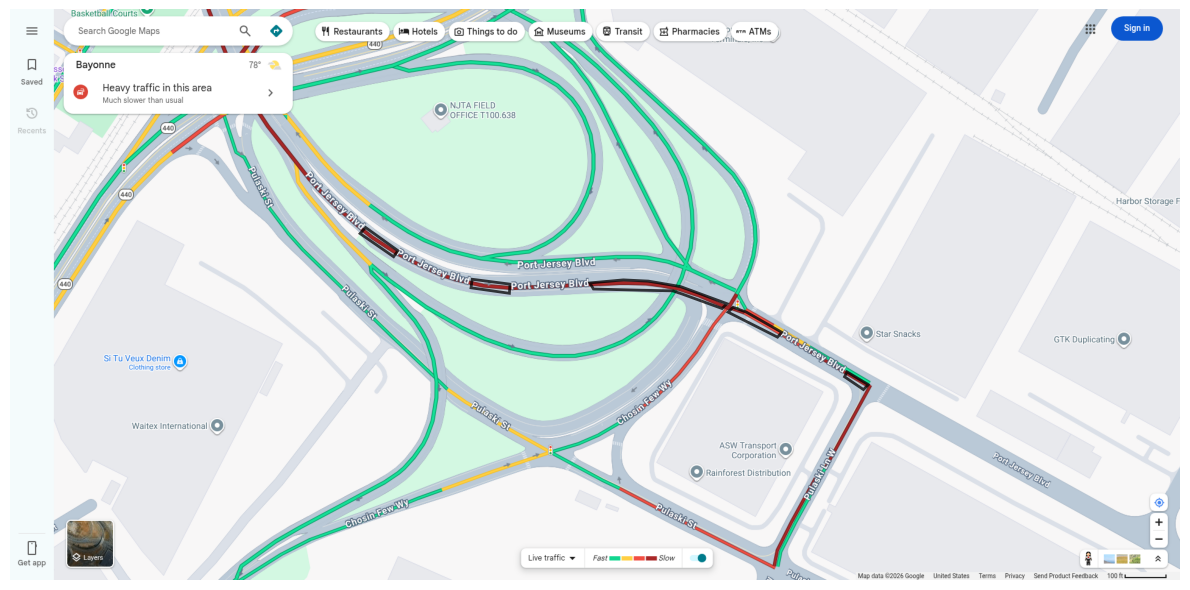

In [50]:
show_rois_on_image(
    image_path=image_path,
    roi_mapping=workbooks_config[r"Port Jersey Blvd"]["roi_mapping"],
    show_labels=False
)

# Pixel Counter

In [31]:
# Constants
TARGET_COLORS = [(252, 205, 73), (22, 224, 152), (205, 98, 68), (183, 52, 55)]

# Corresponding normalized colors mapped to traffic labels (only the main traffic colors)
COLOR_LABELS = {
    (22/255, 224/255, 152/255): 'Light Traffic',
    (252/255, 205/255, 73/255): 'Moderate Traffic',
    (205/255, 98/255, 68/255): 'Heavy Traffic',
    (183/255, 52/255, 55/255): 'Severe Traffic'
}

# --- Utility Functions ---
def extract_date_and_time_from_filename(file_path):
    try:
        file_name = os.path.basename(file_path)
        name_without_ext = os.path.splitext(file_name)[0]
        file_name_parts = name_without_ext.split('_')
        date_time_str = file_name_parts[-2] + '_' + file_name_parts[-1]
        return datetime.strptime(date_time_str, '%Y-%m-%d_%H%M')
    except Exception as e:
        print(f"[ERROR] Filename parsing failed for {file_path}: {e}")
        return None


def count_rgb_colors(image_path, roi=None, show_images=False):
    image = Image.open(image_path).convert('RGB')

    if show_images:
        print('Original Image:')
        display(image)

    if isinstance(roi, tuple):  # Rectangular crop
        image = image.crop(roi)

    elif isinstance(roi, list):  # Polygonal ROI
        # Compute bounding box
        xs, ys = zip(*roi)
        bbox = (min(xs), min(ys), max(xs), max(ys))

        # Crop image to polygon bounding box
        cropped_image = image.crop(bbox)

        # Offset polygon points to cropped box coordinates
        offset_polygon = [(x - bbox[0], y - bbox[1]) for x, y in roi]

        # Create a new mask for the cropped image
        mask = Image.new("L", cropped_image.size, 0)
        ImageDraw.Draw(mask).polygon(offset_polygon, fill=255)

        # Apply mask to cropped image
        image = Image.new("RGB", cropped_image.size)
        image.paste(cropped_image, mask=mask)

    if show_images:
        print("Cropped Images (ROI):")
        display(image)

    palette_colors = [
        (252, 205, 73),   # Warm Yellow / Moderate Traffic
        (22, 224, 152),   # Bright Turquoise / Light Traffic
        (183, 52, 55),    # Dark Red / Severe Traffic
        (205, 98, 68),    # Rusty Orange / Heavy Traffic
        (144, 218, 238),  # Light Sky Blue / Background/Water
        (245, 243, 243),  # Very Light Gray / Background/Neutral
        (195, 241, 213),  # Pale Mint Green / Vegetation/Calm Area
        (248, 240, 222),  # Light Beige / Background/Road
        (123, 142, 154),  # Grayish Blue / Infrastructure/Shadows
        (108, 163, 189),  # Soft Medium Blue / Water/Neutral
        (83, 88, 103)]     # Dark Grayish Blue / Road Markings/Shaded

    palette_image = Image.new('P', (1, 1))
    palette_image.putpalette([c for color in palette_colors for c in color])
    posterized_image = image.quantize(palette=palette_image).convert('RGB')

    if show_images:
        print('Posterized Image:')
        display(posterized_image)

    # pixels = list(posterized_image.getdata())
    pixels = list(posterized_image.get_flattened_data())
    rgb_counts = {}
    for pixel in pixels:
        rgb_counts[pixel[:3]] = rgb_counts.get(pixel[:3], 0) + 1

    filtered_counts = {
        tuple([r / 255, g / 255, b / 255]): rgb_counts.get((r, g, b), 0)
        for r, g, b in TARGET_COLORS
    }

    return filtered_counts, os.path.splitext(os.path.basename(image_path))[0]

def analyze_images_by_roi(
    folder_path,
    roi_mapping,
    show_images=False,
    image_files=None,
    start_datetime=None,
    end_datetime=None,
    freq="15min"
):

    if roi_mapping is None:
        roi_mapping = {"FullImage": None}

    # --------------------------------------------------
    # Get image files
    # --------------------------------------------------

    if image_files is None:
        image_files = glob.glob(
            os.path.join(folder_path, "**", "*.png"),
            recursive=True
        )
    else:
        image_files = [os.path.join(folder_path, f) for f in image_files]

    # --------------------------------------------------
    # Extract actual image timestamps and assign each
    # image to nearest 15-minute slot
    # --------------------------------------------------

    image_records = []

    for image_path in image_files:

        actual_dt = extract_date_and_time_from_filename(image_path)

        if actual_dt is None:
            continue

        actual_dt = pd.Timestamp(actual_dt)
        slot_dt = actual_dt.round(freq)

        image_records.append({
            "image_path": image_path,
            "actual_datetime": actual_dt,
            "slot_datetime": slot_dt,
            "time_offset": abs(actual_dt - slot_dt)
        })

    if not image_records:
        print("[WARNING] No valid image timestamps found.")
        return pd.DataFrame()

    image_records = pd.DataFrame(image_records)

    # --------------------------------------------------
    # If multiple images map to the same slot,
    # keep the one closest to the intended slot
    # --------------------------------------------------

    image_records = (
        image_records
        .sort_values("time_offset")
        .drop_duplicates(
            subset="slot_datetime",
            keep="first"
        )
        .sort_values("slot_datetime")
        .reset_index(drop=True)
    )

    # --------------------------------------------------
    # Determine timeline start/end
    # --------------------------------------------------

    if start_datetime is None:
        start_datetime = image_records["slot_datetime"].min()
    else:
        start_datetime = pd.Timestamp(start_datetime).round(freq)

    if end_datetime is None:
        end_datetime = image_records["slot_datetime"].max()
    else:
        end_datetime = pd.Timestamp(end_datetime).round(freq)

    # --------------------------------------------------
    # Build complete expected timeline FIRST
    # --------------------------------------------------

    expected_dates = pd.date_range(
        start=start_datetime,
        end=end_datetime,
        freq=freq
    )

    combined_df = pd.DataFrame({
        "Dates": expected_dates
    })

    # --------------------------------------------------
    # Add image metadata
    # --------------------------------------------------

    image_metadata = image_records[
        [
            "slot_datetime",
            "actual_datetime",
            "image_path"
        ]
    ].rename(
        columns={
            "slot_datetime": "Dates",
            "actual_datetime": "Image Timestamp",
            "image_path": "Image Path"
        }
    )

    combined_df = combined_df.merge(
        image_metadata,
        on="Dates",
        how="left"
    )

    combined_df["Image Available"] = (
        combined_df["Image Timestamp"].notna()
    )

    # --------------------------------------------------
    # Process each ROI
    # --------------------------------------------------

    for roi_name, roi_coords in roi_mapping.items():

        print(f"\nProcessing ROI: {roi_name} -> {roi_coords}")

        rows = []

        for _, image_row in image_records.iterrows():

            image_path = image_row["image_path"]
            slot_datetime = image_row["slot_datetime"]

            print(image_path)

            try:

                counts, _ = count_rgb_colors(
                    image_path,
                    roi=roi_coords,
                    show_images=show_images
                )

            except Exception as e:

                print(
                    f"[WARNING] Skipping corrupted or unreadable image: "
                    f"{image_path} -> {e}"
                )

                continue

            row = {
                "Dates": slot_datetime
            }

            for color, label in COLOR_LABELS.items():

                row[f"{roi_name} {label}"] = counts.get(
                    color,
                    0
                )

            rows.append(row)

        # --------------------------------------------------
        # Merge ROI results onto complete timeline
        # --------------------------------------------------

        if rows:

            df_zone = pd.DataFrame(rows)

            combined_df = combined_df.merge(
                df_zone,
                on="Dates",
                how="left"
            )

    return combined_df


# Count Pixels

In [310]:
import pytz
import time

In [311]:
utc_now = datetime.now(pytz.utc)
et_tz = pytz.timezone("US/Eastern")
present_time = utc_now.astimezone(et_tz)

# weekday(): Monday=0, Tuesday=1, ..., Sunday=6
today = present_time.date()

In [312]:
today

datetime.date(2026, 9, 24)

In [64]:
for setting_name, config in workbooks_config.items():
        print(f"\n📊 Processing routes for: {setting_name}")
        df = analyze_images_by_roi(
            folder_path=os.path.join(config["folder_path"], day_folder),
            roi_mapping=config["roi_mapping"],
            image_files=[os.path.basename(image_path)]
        )


📊 Processing routes for: Port Jersey Blvd

Processing ROI: zone_1 -> [(1408, 616), (1373, 595), (1369, 603), (1400, 624)]
C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey\09_18_2026\Port Liberty New Jersey_2026-09-18_1221.png

Processing ROI: zone_2 -> [(1266, 530), (1208, 497), (1186, 489), (1178, 497), (1259, 538)]
C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey\09_18_2026\Port Liberty New Jersey_2026-09-18_1221.png

Processing ROI: zone_3 -> [(1176, 483), (1100, 455), (1047, 446), (1006, 444), (951, 449), (957, 459), (1036, 461), (1087, 462), (1102, 467), (1168, 491)]
C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey\09_18_2026\Port Liberty Ne

In [65]:
df

,Dates,Image Timestamp,Image Available,zone_1 Light Traffic,zone_1 Moderate Traffic,zone_1 Heavy Traffic,zone_1 Severe Traffic,zone_2 Light Traffic,zone_2 Moderate Traffic,zone_2 Heavy Traffic,zone_2 Severe Traffic,zone_3 Light Traffic,zone_3 Moderate Traffic,zone_3 Heavy Traffic,zone_3 Severe Traffic,zone_4 Light Traffic,zone_4 Moderate Traffic,zone_4 Heavy Traffic,zone_4 Severe Traffic,zone_5 Light Traffic,zone_5 Moderate Traffic,zone_5 Heavy Traffic,zone_5 Severe Traffic
0,2026-09-18 12:15:00,2026-09-18 12:21:00,True,0,0,2,133,0,0,168,274,12,0,27,1046,0,0,10,305,0,0,4,335


In [67]:
workbooks_config.items()

dict_items([('Port Jersey Blvd', {'folder_path': 'C:\\Users\\dane.rini\\Global Infrastructure\\SSC PANYNJ Team - Documents\\01 - PANYNJ\\10 - Google Screenshot\\01 - All Inbound Google Screenshots\\Port Liberty New Jersey', 'roi_mapping': {'zone_1': [(1408, 616), (1373, 595), (1369, 603), (1400, 624)], 'zone_2': [(1266, 530), (1208, 497), (1186, 489), (1178, 497), (1259, 538)], 'zone_3': [(1176, 483), (1100, 455), (1047, 446), (1006, 444), (951, 449), (957, 459), (1036, 461), (1087, 462), (1102, 467), (1168, 491)], 'zone_4': [(820, 451), (758, 443), (756, 457), (819, 466)], 'zone_5': [(636, 396), (583, 358), (574, 368), (629, 406)]}})])

# Process pixels for several images

In [79]:
master_df = None

for setting_name, config in workbooks_config.items():
    print(f"\n📊 Processing routes for: {setting_name}")
    df = analyze_images_by_roi(
        folder_path=config["folder_path"],
        roi_mapping=config["roi_mapping"],
        show_images=False
    )
    if master_df is None:
        master_df = df
    else:
        master_df = pd.merge(master_df, df, on="Dates", how="outer")

# Save final combined file
output_path = r"C:\Users\dane.rini\source\repos\panynj_port_liberty_google_screenshots\port_lib_zone_pixels.xlsx"
with pd.ExcelWriter(output_path, engine='xlsxwriter') as writer:
    master_df.sort_values("Dates").to_excel(writer, sheet_name="All_Zones", index=False)

print(f"\n✅ Master Excel report saved to: {output_path}")



📊 Processing routes for: Port Jersey Blvd

Processing ROI: zone_1 -> [(1408, 616), (1373, 595), (1369, 603), (1400, 624)]
C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey\08_13_2026\Port Liberty New Jersey_2026-08-13_1207.png
C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey\08_13_2026\Port Liberty New Jersey_2026-08-13_1221.png
C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey\08_13_2026\Port Liberty New Jersey_2026-08-13_1236.png
C:\Users\dane.rini\Global Infrastructure\SSC PANYNJ Team - Documents\01 - PANYNJ\10 - Google Screenshot\01 - All Inbound Google Screenshots\Port Liberty New Jersey\08_13_2026\Port Liberty New Jersey_2026-08-13_1256.png
C

# Pixel thresholding review

## Pull pixel counts export for review if kernel is restarted

In [34]:
master_df = pd.read_excel(r"C:\Users\dane.rini\source\repos\panynj_port_liberty_google_screenshots\port_lib_zone_pixels_RAW.xlsx")

## First, filtering by time of day: 5a-5p

In [35]:
start_time = "05:00"
end_time = "17:00"

master_df_filtered = master_df[
    master_df["Dates"].dt.time.between(
        pd.to_datetime(start_time).time(),
        pd.to_datetime(end_time).time()
    )
]

# master_df_filtered = master_df.copy()

## Defining total pixels for each route

In [36]:
master_df_filtered['zone_1_total'] = master_df_filtered.filter(regex='^zone_1').sum(axis=1, min_count=1)
master_df_filtered['zone_2_total'] = master_df_filtered.filter(regex='^zone_2').sum(axis=1, min_count=1)
master_df_filtered['zone_3_total'] = master_df_filtered.filter(regex='^zone_3').sum(axis=1, min_count=1)
master_df_filtered['zone_4_total'] = master_df_filtered.filter(regex='^zone_4').sum(axis=1, min_count=1)
master_df_filtered['zone_5_total'] = master_df_filtered.filter(regex='^zone_5').sum(axis=1, min_count=1)

In [345]:
master_df_filtered.filter(regex='^zone_3').sort_values('zone_3_total', ascending=False)

,zone_3 Light Traffic,zone_3 Moderate Traffic,zone_3 Heavy Traffic,zone_3 Severe Traffic,zone_3_total
3468,14.0,1482.0,86.0,1.0,1583.0
3454,14.0,1039.0,273.0,202.0,1528.0
3362,14.0,1039.0,273.0,202.0,1528.0
373,14.0,1039.0,273.0,202.0,1528.0
3278,14.0,1039.0,273.0,202.0,1528.0
...,...,...,...,...,...
569,NaN,NaN,NaN,NaN,NaN
1171,NaN,NaN,NaN,NaN,NaN
1744,NaN,NaN,NaN,NaN,NaN
2373,NaN,NaN,NaN,NaN,NaN


## Checking statistics on pixel counts for each route

In [346]:
master_df_filtered[master_df_filtered['Dates'] == '8/13/2026  12:45:00 PM']

,Dates,Image Timestamp,Image Path,Image Available,zone_1 Light Traffic,zone_1 Moderate Traffic,zone_1 Heavy Traffic,zone_1 Severe Traffic,zone_2 Light Traffic,zone_2 Moderate Traffic,zone_2 Heavy Traffic,zone_2 Severe Traffic,zone_3 Light Traffic,zone_3 Moderate Traffic,zone_3 Heavy Traffic,zone_3 Severe Traffic,zone_4 Light Traffic,zone_4 Moderate Traffic,zone_4 Heavy Traffic,zone_4 Severe Traffic,zone_5 Light Traffic,zone_5 Moderate Traffic,zone_5 Heavy Traffic,zone_5 Severe Traffic,zone_1_total,zone_2_total,zone_3_total,zone_4_total,zone_5_total
3,2026-08-13 12:45:00,NaT,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print(master_df_filtered['zone_1_total'].describe(percentiles=[0.01, 0.05, 0.09, 0.1, 0.95]))
print(master_df_filtered['zone_2_total'].describe(percentiles=[0.01, 0.05, 0.09, 0.1, 0.95]))
print(master_df_filtered['zone_3_total'].describe(percentiles=[0.01, 0.05, 0.09, 0.1, 0.95]))
print(master_df_filtered['zone_4_total'].describe(percentiles=[0.01, 0.05, 0.09, 0.1, 0.95]))
print(master_df_filtered['zone_5_total'].describe(percentiles=[0.01, 0.05, 0.09, 0.1, 0.95]))

count    1777.000000
mean      152.460889
std        46.073394
min         0.000000
1%          0.000000
5%          0.000000
9%        152.000000
10%       152.000000
95%       169.000000
max       232.000000
Name: zone_1_total, dtype: float64
count    1777.000000
mean      363.398424
std       107.617294
min         0.000000
1%          0.000000
5%          0.000000
9%        331.000000
10%       367.000000
95%       406.000000
max       507.000000
Name: zone_2_total, dtype: float64
count    1777.000000
mean     1213.362971
std       275.316661
min         0.000000
1%          0.000000
5%        276.000000
9%       1087.000000
10%      1226.600000
95%      1353.000000
max      1583.000000
Name: zone_3_total, dtype: float64
count    1777.000000
mean      300.701745
std        77.013702
min         0.000000
1%          0.000000
5%          0.000000
9%        320.000000
10%       320.000000
95%       320.000000
max       395.000000
Name: zone_4_total, dtype: float64
count    1777.000000

## Checking low end pixel counts

In [297]:
pd.set_option('display.max_colwidth', None)

In [298]:
master_df_filtered.dtypes

Dates                      datetime64[us]
Image Timestamp            datetime64[us]
Image Path                            str
Image Available                      bool
zone_1 Light Traffic              float64
zone_1 Moderate Traffic           float64
zone_1 Heavy Traffic              float64
zone_1 Severe Traffic             float64
zone_2 Light Traffic              float64
zone_2 Moderate Traffic           float64
zone_2 Heavy Traffic              float64
zone_2 Severe Traffic             float64
zone_3 Light Traffic              float64
zone_3 Moderate Traffic           float64
zone_3 Heavy Traffic              float64
zone_3 Severe Traffic             float64
zone_4 Light Traffic              float64
zone_4 Moderate Traffic           float64
zone_4 Heavy Traffic              float64
zone_4 Severe Traffic             float64
zone_5 Light Traffic              float64
zone_5 Moderate Traffic           float64
zone_5 Heavy Traffic              float64
zone_5 Severe Traffic             

## Showing ROI on low pixel images

In [37]:
zone_1_threshold = master_df_filtered['zone_1_total'].quantile(0.95) * 2 / 3
zone_2_threshold = master_df_filtered['zone_2_total'].quantile(0.95) * 2 / 3
zone_3_threshold = master_df_filtered['zone_3_total'].quantile(0.95) * 2 / 3
zone_4_threshold = master_df_filtered['zone_4_total'].quantile(0.95) * 2 / 3
zone_5_threshold = master_df_filtered['zone_5_total'].quantile(0.95) * 2 / 3

# zone_1_threshold = master_df_filtered['zone_1_total'].quantile(0.09)
# zone_2_threshold = master_df_filtered['zone_2_total'].quantile(0.09)
# zone_3_threshold = master_df_filtered['zone_3_total'].quantile(0.09)
# zone_4_threshold = master_df_filtered['zone_4_total'].quantile(0.09)
# zone_5_threshold = master_df_filtered['zone_5_total'].quantile(0.09)

thresholds = [
    zone_1_threshold,
    zone_2_threshold,
    zone_3_threshold,
    zone_4_threshold,
    zone_5_threshold]

thresholds

[np.float64(112.66666666666667),
 np.float64(270.6666666666667),
 np.float64(902.0),
 np.float64(213.33333333333334),
 np.float64(236.66666666666666)]

In [32]:
zone_number = 3
# zone_threshold = 337
zone_threshold = thresholds[zone_number - 1] + 150
print(zone_threshold)
low_end_pixel_images = master_df_filtered[(master_df_filtered[f'zone_{zone_number}_total'] < zone_threshold) &
          (master_df_filtered[f'zone_{zone_number}_total'] != 0)][['Dates', 'Image Timestamp', 'Image Path', 'Image Available', 
                                             f'zone_{zone_number} Light Traffic',
                                             f'zone_{zone_number} Moderate Traffic',
                                             f'zone_{zone_number} Heavy Traffic',
                                             f'zone_{zone_number} Severe Traffic',
                                             f'zone_{zone_number}_total']].sort_values(by=f'zone_{zone_number}_total', ascending=False)

low_low = low_end_pixel_images[:5]
print(low_end_pixel_images[f'zone_{zone_number}_total'].max())
for index, row in low_low.iterrows():
    print(row[f'zone_{zone_number}_total'])

    show_rois_on_image(
        image_path=row['Image Path'],
        roi_mapping=workbooks_config[r"Port Jersey Blvd"]["roi_mapping"],
        show_labels=False
    )

1954.0
1800.0
1800.0


NameError: name 'show_rois_on_image' is not defined

# Defining pixel thresholds by zone

In [38]:
zone_1_threshold = master_df_filtered['zone_1_total'].quantile(0.95) * 2 / 3
zone_2_threshold = master_df_filtered['zone_2_total'].quantile(0.95) * 2 / 3 
# zone_3_threshold = master_df_filtered['zone_3_total'].quantile(0.95) * 2 / 3 #1080
zone_3_threshold = 1080
zone_4_threshold = master_df_filtered['zone_4_total'].quantile(0.95) * 2 / 3
zone_5_threshold = master_df_filtered['zone_5_total'].quantile(0.95) * 2 / 3

thresholds = [
    zone_1_threshold,
    zone_2_threshold,
    zone_3_threshold,
    zone_4_threshold,
    zone_5_threshold]

thresholds

[np.float64(112.66666666666667),
 np.float64(270.6666666666667),
 1080,
 np.float64(213.33333333333334),
 np.float64(236.66666666666666)]

In [350]:
zone_1_threshold

np.float64(112.66666666666667)

## Dropping zone data that does not meet threshold

In [43]:
# Pulling zone pixel thresholds
zone_thresholds = {
    "zone_1": zone_1_threshold,
    "zone_2": zone_2_threshold,
    "zone_3": zone_3_threshold,
    "zone_4": zone_4_threshold,
    "zone_5": zone_5_threshold,
}

#initialize cleaned dataframe
master_df_dropped = master_df_filtered.copy()

# Setting processing description column
master_df_dropped["Image Status"] = (
    master_df_dropped["Image Available"]
    .map({
        True: "True",
        False: "No screenshot"
    })
)

# Track whether ANY zone gets dropped on each row
zones_dropped = pd.Series(False, index=master_df.index)
qa_rows = []

for zone, threshold in zone_thresholds.items():

    total_col = f"{zone}_total"

    drop_mask_zero = (
        master_df_filtered["Image Available"].eq(True)
        & master_df_filtered[total_col].eq(0)
    )

    drop_mask_threshold = (
        master_df_filtered["Image Available"].eq(True)
        & master_df_filtered[total_col].notna()
        & (master_df_filtered[total_col] < threshold)
    )

    zero_pct = 100 * drop_mask_zero.sum() / len(drop_mask_zero)
    threshold_pct = 100 * drop_mask_threshold.sum() / len(drop_mask_threshold)


    print(f'Zero rows dropped from zone {zone}: {drop_mask_zero.sum()}')
    print(f"% Zero rows dropped from zone {zone}: {zero_pct:.2f}%")

    print(f"Zero + Threshold rows dropped from zone {zone}: {drop_mask_threshold.sum()}")
    print(f"% Zero + Threshold rows dropped from zone {zone}: {threshold_pct:.2f}%\n")    

    qa_rows.append({
        "Zone": zone,
        "Threshold": threshold,
        "Zero Rows Dropped": drop_mask_zero.sum(),
        "Zero Rows Dropped (%)": zero_pct,
        "Zero + Threshold Rows Dropped": drop_mask_threshold.sum(),
        "Zero + Threshold Rows Dropped (%)": threshold_pct,
    })

    drop_mask = drop_mask_zero | drop_mask_threshold

    # Find all columns belonging to this zone
    zone_cols = [
        col for col in master_df_dropped.columns
        if col.startswith(f"{zone} ")
    ]

    # Blank ONLY this zone's data
    master_df_dropped.loc[drop_mask, zone_cols] = pd.NA

    # Record that at least one zone was dropped
    zones_dropped |= drop_mask

    master_df_dropped.loc[
        master_df_dropped["Image Available"].eq(True) & zones_dropped,
        "Image Status"
    ] = "Has screenshot, has invalid zones(s)"

    master_df_dropped.loc[
        master_df_dropped["Image Available"].eq(True) & ~zones_dropped,
        "Image Status"
    ] = "Has screenshot, all zones valid"

qa_df = pd.DataFrame(qa_rows)

Zero rows dropped from zone zone_1: 144
% Zero rows dropped from zone zone_1: 8.07%
Zero + Threshold rows dropped from zone zone_1: 144
% Zero + Threshold rows dropped from zone zone_1: 8.07%

Zero rows dropped from zone zone_2: 134
% Zero rows dropped from zone zone_2: 7.51%
Zero + Threshold rows dropped from zone zone_2: 149
% Zero + Threshold rows dropped from zone zone_2: 8.35%

Zero rows dropped from zone zone_3: 23
% Zero rows dropped from zone zone_3: 1.29%
Zero + Threshold rows dropped from zone zone_3: 151
% Zero + Threshold rows dropped from zone zone_3: 8.46%

Zero rows dropped from zone zone_4: 108
% Zero rows dropped from zone zone_4: 6.05%
Zero + Threshold rows dropped from zone zone_4: 110
% Zero + Threshold rows dropped from zone zone_4: 6.16%

Zero rows dropped from zone zone_5: 107
% Zero rows dropped from zone zone_5: 5.99%
Zero + Threshold rows dropped from zone zone_5: 107
% Zero + Threshold rows dropped from zone zone_5: 5.99%



In [23]:
master_df_dropped[master_df_dropped['Image Status'] == 'Has screenshot, has invalid zones(s)']

,Dates,Image Timestamp,Image Path,Image Available,zone_1 Light Traffic,zone_1 Moderate Traffic,zone_1 Heavy Traffic,zone_1 Severe Traffic,zone_2 Light Traffic,zone_2 Moderate Traffic,zone_2 Heavy Traffic,zone_2 Severe Traffic,zone_3 Light Traffic,zone_3 Moderate Traffic,zone_3 Heavy Traffic,zone_3 Severe Traffic,zone_4 Light Traffic,zone_4 Moderate Traffic,zone_4 Heavy Traffic,zone_4 Severe Traffic,zone_5 Light Traffic,zone_5 Moderate Traffic,zone_5 Heavy Traffic,zone_5 Severe Traffic,zone_1_total,zone_2_total,zone_3_total,zone_4_total,zone_5_total,Image Status
69,2026-08-14 05:15:00,2026-08-14 05:21:00,C:\Users\dane.rini\Global Infrastructure\SSC P...,True,152.0,1.0,0.0,0.0,287.0,0.0,39.0,68.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,153.0,394.0,52.0,0.0,0.0,"Has screenshot, has invalid zones(s)"
164,2026-08-15 05:00:00,2026-08-15 05:06:00,C:\Users\dane.rini\Global Infrastructure\SSC P...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,52.0,0.0,0.0,"Has screenshot, has invalid zones(s)"
165,2026-08-15 05:15:00,2026-08-15 05:21:00,C:\Users\dane.rini\Global Infrastructure\SSC P...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,"Has screenshot, has invalid zones(s)"
166,2026-08-15 05:30:00,2026-08-15 05:36:00,C:\Users\dane.rini\Global Infrastructure\SSC P...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,"Has screenshot, has invalid zones(s)"
167,2026-08-15 05:45:00,2026-08-15 05:51:00,C:\Users\dane.rini\Global Infrastructure\SSC P...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,277.0,0.0,0.0,"Has screenshot, has invalid zones(s)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3045,2026-09-14 05:15:00,2026-09-14 05:21:00,C:\Users\dane.rini\Global Infrastructure\SSC P...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,869.0,432.0,23.0,0.0,320.0,0.0,0.0,0.0,351.0,0.0,0.0,0.0,0.0,0.0,1324.0,320.0,351.0,"Has screenshot, has invalid zones(s)"
3238,2026-09-16 05:30:00,2026-09-16 05:36:00,C:\Users\dane.rini\Global Infrastructure\SSC P...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,320.0,0.0,0.0,0.0,351.0,0.0,0.0,0.0,0.0,0.0,1048.0,320.0,351.0,"Has screenshot, has invalid zones(s)"
3370,2026-09-17 14:30:00,2026-09-17 14:36:00,C:\Users\dane.rini\Global Infrastructure\SSC P...,True,0.0,0.0,8.0,147.0,NaN,NaN,NaN,NaN,15.0,1.0,718.0,713.0,211.0,0.0,53.0,72.0,0.0,0.0,191.0,233.0,155.0,269.0,1447.0,336.0,424.0,"Has screenshot, has invalid zones(s)"
3430,2026-09-18 05:30:00,2026-09-18 05:36:00,C:\Users\dane.rini\Global Infrastructure\SSC P...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,276.0,0.0,0.0,"Has screenshot, has invalid zones(s)"


In [44]:
new_order = ['Dates', 'Image Timestamp', 
            'zone_1 Light Traffic', 'zone_1 Moderate Traffic', 'zone_1 Heavy Traffic', 'zone_1 Severe Traffic', 
            'zone_2 Light Traffic', 'zone_2 Moderate Traffic', 'zone_2 Heavy Traffic', 'zone_2 Severe Traffic', 
            'zone_3 Light Traffic', 'zone_3 Moderate Traffic', 'zone_3 Heavy Traffic', 'zone_3 Severe Traffic', 
            'zone_4 Light Traffic', 'zone_4 Moderate Traffic', 'zone_4 Heavy Traffic', 'zone_4 Severe Traffic', 
            'zone_5 Light Traffic', 'zone_5 Moderate Traffic', 'zone_5 Heavy Traffic', 'zone_5 Severe Traffic',
            'Image Status']

In [45]:
master_df = (
            master_df_dropped
            .reindex(columns=new_order)
            .sort_values("Dates")
            .reset_index(drop=True)
        )

In [21]:
master_df['Image Status'].value_counts()

Image Status
Has screenshot, all zones valid         1605
Has screenshot, has invalid zones(s)     172
No screenshot                              8
Name: count, dtype: int64

In [47]:
with pd.ExcelWriter(r"C:\Users\dane.rini\source\repos\panynj_port_liberty_google_screenshots\port_lib_zone_pixels_CLEANED.xlsx", engine="xlsxwriter") as writer:
            master_df.to_excel(
                writer,
                sheet_name="All_Zones",
                index=False,
            )

            qa_df.to_excel(
                writer,
                sheet_name="QA_Summary",
                index=False
            )

In [ ]:
master_df.to_excel(r"C:\Users\dane.rini\source\repos\panynj_port_liberty_google_screenshots\port_lib_zone_pixels_CLEANED.xlsx")